In [5]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

### Problem 1

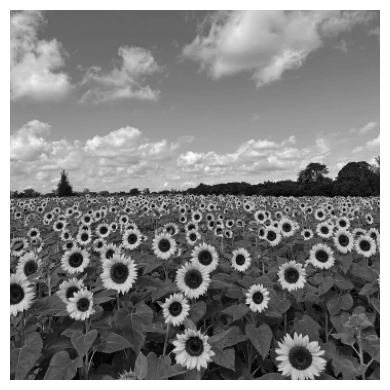

Image shape: (360, 360, 3)
Grayscale shape: (360, 360)


In [28]:
# Load the image
im = cv.imread('src/the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)

# Convert to grayscale
im_gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)

# Display the original image
plt.figure(figsize=(4, 4))
plt.imshow(im_gray, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Image shape: {im.shape}")
print(f"Grayscale shape: {im_gray.shape}")

In [ ]:
def laplacian_of_gaussian(image, sigma):
    # Apply Gaussian blur
    blurred = cv.GaussianBlur(image.astype(float), (0, 0), sigma)
    
    # Apply Laplacian
    laplacian = cv.Laplacian(blurred, cv.CV_64F)
    
    # Scale normalization: multiply by sigma^2
    # Take absolute value because we're looking for bright blobs on dark background
    return np.abs(sigma**2 * laplacian)

In [9]:
# Select range of sigma values (geometric progression to cover small to large blobs)
sigma_values = np.logspace(np.log10(1.2), np.log10(12.0), num=18)
threshold = 0.045
nms_size = (3, 3, 3)
max_blobs = 200

scale_space = []
print("Computing scale-normalized LoG responses...")
for sigma in sigma_values:
    print(f"  sigma = {sigma:.2f}")
    response = laplacian_of_gaussian(im_gray, sigma)
    response_abs = np.abs(response)
    response_norm = cv.normalize(response_abs, None, 0, 1, cv.NORM_MINMAX)
    scale_space.append(response_norm.astype(np.float32))
    
scale_space = np.stack(scale_space, axis=0)
max_filtered = ndimage.maximum_filter(scale_space, size=nms_size, mode='reflect')
candidate_mask = (scale_space == max_filtered) & (scale_space >= threshold)
candidate_indices = np.argwhere(candidate_mask)
print(f"Total candidates after NMS: {len(candidate_indices)}")

detections = []
for scale_idx, y, x in candidate_indices:
    sigma = float(sigma_values[scale_idx])
    center = (int(x), int(y))
    radius = float(np.sqrt(2) * sigma)
    response_value = float(scale_space[scale_idx, y, x])
    detections.append((center, radius, sigma, response_value))

detections.sort(key=lambda item: item[3], reverse=True)

blob_responses = []
for center, radius, sigma, response_value in detections:
    if len(blob_responses) >= max_blobs:
        break
    keep = True
    for chosen_center, chosen_radius, _, _ in blob_responses:
        dist = np.hypot(center[0] - chosen_center[0], center[1] - chosen_center[1])
        min_sep = 0.6 * max(radius, chosen_radius)
        if dist < min_sep:
            keep = False
            break
    if keep:
        blob_responses.append((center, radius, sigma, response_value))

print(f"Blobs kept after spatial suppression: {len(blob_responses)}")

Computing scale-normalized LoG responses...
  sigma = 1.20
  sigma = 1.37
  sigma = 1.57
  sigma = 1.80
  sigma = 2.06
  sigma = 2.36
  sigma = 2.70
  sigma = 3.10
  sigma = 3.55
  sigma = 4.06
  sigma = 4.65
  sigma = 5.32
  sigma = 6.10
  sigma = 6.98
  sigma = 7.99
  sigma = 9.15
  sigma = 10.48
  sigma = 12.00
Total candidates after NMS: 5282
Blobs kept after spatial suppression: 200


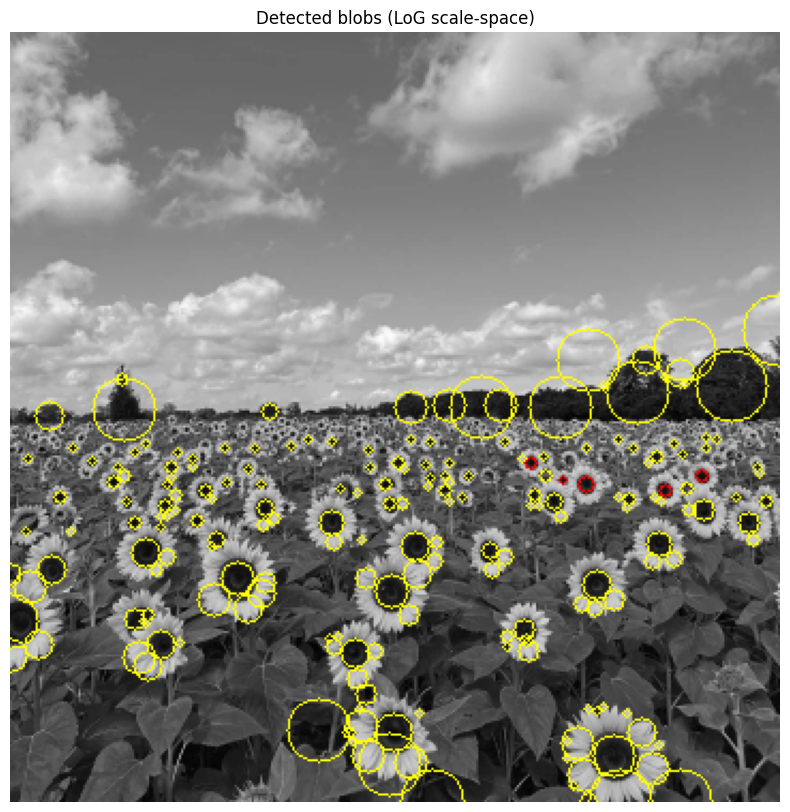

Sigma range: 1.20 – 12.00 (total 18 scales)
Largest blob at : (337, 165) with radius 17.0 px and sigma 12.00
Top 5 blobs by radius:
  1. center=(337, 165), radius=17.0px, sigma=12.00, response=0.994
  2. center=(359, 139), radius=17.0px, sigma=12.00, response=0.722
  3. center=(293, 168), radius=14.8px, sigma=10.48, response=1.000
  4. center=(53, 176), radius=14.8px, sigma=10.48, response=0.888
  5. center=(257, 175), radius=14.8px, sigma=10.48, response=0.854


In [10]:
# Draw all detected circles with the specified line thickness
output = cv.cvtColor(im_gray, cv.COLOR_GRAY2BGR)
for rank, (center, radius, sigma, response_value) in enumerate(blob_responses):
    color = (0, 255, 255) if rank >= 5 else (0, 0, 255)
    cv.circle(output, center, int(round(radius)), color, 1)

# Display the grayscale image with detected circles
plt.figure(figsize=(10, 10))
plt.imshow(cv.cvtColor(output, cv.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Detected blobs (LoG scale-space)')
plt.show()

sigma_min, sigma_max = float(sigma_values[0]), float(sigma_values[-1])
print(f"Sigma range: {sigma_min:.2f} – {sigma_max:.2f} (total {len(sigma_values)} scales)")

if blob_responses:
    blobs_sorted = sorted(blob_responses, key=lambda x: x[1], reverse=True)
    largest_blob = blobs_sorted[0]
    center, radius, sigma = largest_blob[:3]
    print(f"Largest blob at : {center} with radius {radius:.1f} px and sigma {sigma:.2f}")
    print("Top 5 blobs by radius:")
    for idx, (c, r, s, resp) in enumerate(blobs_sorted[:5], start=1):
        print(f"  {idx}. center={c}, radius={r:.1f}px, sigma={s:.2f}, response={resp:.3f}")
else:
    print("No blobs detected above the threshold.")

### Problem 3 - Image Superimposing

In [26]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def superimpose_image_with_homography(base_path, overlay_path, window_title="Base Image", output_title="Result"):
    clicked_points = []

    # Load images
    base_img_bgr = cv.imread(base_path)
    overlay_bgr = cv.imread(overlay_path)

    if base_img_bgr is None or overlay_bgr is None:
        raise FileNotFoundError(f"Check file paths:\n{base_path}\n{overlay_path}")

    base_img = base_img_bgr.astype(np.float32) / 255.0
    overlay = overlay_bgr.astype(np.float32) / 255.0
    display_img = base_img.copy()

    # Mouse callback to collect 4 points
    def point_selection(action, x, y, flags, param):
        nonlocal clicked_points, display_img
        if action == cv.EVENT_LBUTTONDOWN and len(clicked_points) < 4:
            clicked_points.append((x, y))
            cv.circle(display_img, (x, y), 4, (0, 0, 1), -1)
            cv.imshow(window_title, display_img)

    cv.imshow(window_title, display_img)
    cv.setMouseCallback(window_title, point_selection)

    print("Click four corner points on the target surface in order (clockwise or counterclockwise).")
    while len(clicked_points) < 4:
        if cv.waitKey(20) & 0xFF == 27:
            break
    cv.destroyAllWindows()

    if len(clicked_points) < 4:
        raise RuntimeError("Four destination points were not selected.")

    destination_points = np.array(clicked_points, dtype=np.float32)

    #  Define source points from overlay image 
    h2, w2 = overlay.shape[:2]
    source_points = np.float32([
        [0, 0],
        [w2 - 1, 0],
        [w2 - 1, h2 - 1],
        [0, h2 - 1],
    ])

    # Compute Homography
    H = cv.getPerspectiveTransform(source_points, destination_points)

    # Warp overlay
    warped_overlay = cv.warpPerspective(overlay, H, (base_img.shape[1], base_img.shape[0]))

    # Create mask and blend
    mask = cv.warpPerspective(np.ones((h2, w2), dtype=np.float32), H, (base_img.shape[1], base_img.shape[0]))
    mask = np.clip(mask, 0.0, 1.0)[:, :, None]
    blended = base_img * (1.0 - mask) + warped_overlay * mask

    # Display result
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(cv.cvtColor(base_img, cv.COLOR_BGR2RGB))
    plt.title('Base Image')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv.cvtColor(overlay_bgr.astype(np.float32)/255.0, cv.COLOR_BGR2RGB))
    plt.title('Overlay Image')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv.cvtColor(blended, cv.COLOR_BGR2RGB))
    plt.title(output_title)
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("Image shape:", base_img.shape)
    print("Overlay shape:", overlay.shape)
    print("Selected Points:", clicked_points)
    print("Homography Matrix:\n", H)

    return blended, H, clicked_points


Click four corner points on the target surface in order (clockwise or counterclockwise).


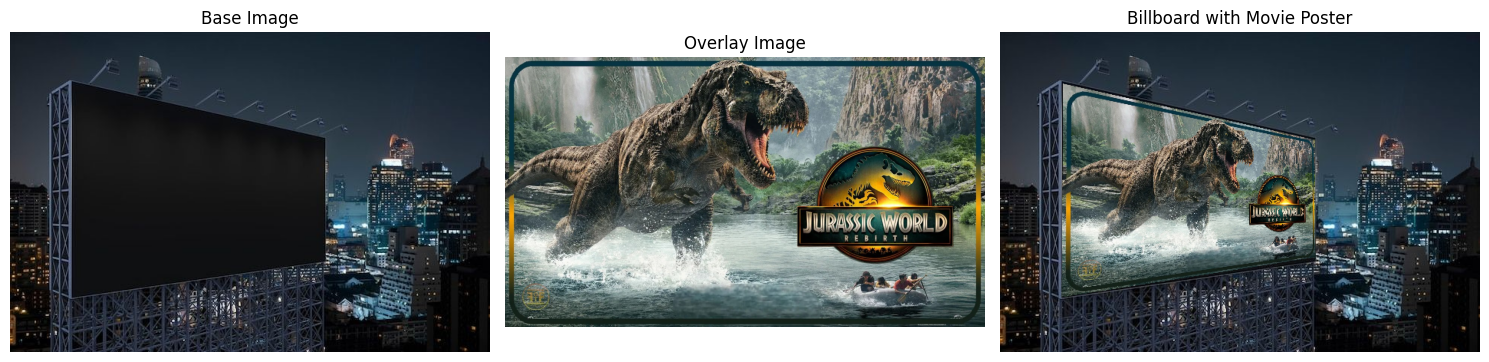

Image shape: (417, 626, 3)
Overlay shape: (720, 1280, 3)
Selected Points: [(82, 67), (410, 140), (411, 293), (80, 345)]
Homography Matrix:
 [[ 5.17093094e-01 -4.06340737e-03  8.20000000e+01]
 [ 1.46075801e-01  3.81120506e-01  6.70000000e+01]
 [ 6.35714005e-04 -1.60220775e-05  1.00000000e+00]]


In [27]:
blended, H, points = superimpose_image_with_homography(
    base_path="src/blank_billboard.jpeg",
    overlay_path="src/movie_poster.jpg",
    output_title='Billboard with Movie Poster'
)


### Problem 4 - Image Stiching

Image 1: 2674 keypoints
Image 5: 3923 keypoints
Raw matches (pairs): 2674
Good matches after ratio test: 87


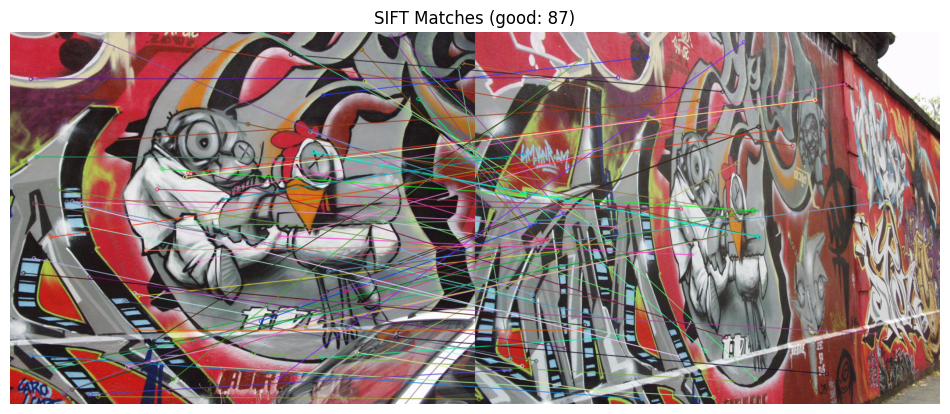

In [30]:
img1_path = "src/graf/img1.ppm"
img5_path = "src/graf/img5.ppm"

# Load images
img1 = cv.imread(img1_path)
img5 = cv.imread(img5_path)
if img1 is None or img5 is None:
    raise FileNotFoundError(f"Could not load")

# Convert to grayscale and RGB
img1_gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)
img5_gray = cv.cvtColor(img5, cv.COLOR_BGR2GRAY)
img1_rgb = cv.cvtColor(img1, cv.COLOR_BGR2RGB)
img5_rgb = cv.cvtColor(img5, cv.COLOR_BGR2RGB)

# Create SIFT detector
sift = cv.SIFT_create()

# Detect keypoints and descriptors
keypoints1, descriptors1 = sift.detectAndCompute(img1_gray, None)
keypoints5, descriptors5 = sift.detectAndCompute(img5_gray, None)

print(f"Image 1: {len(keypoints1)} keypoints")
print(f"Image 5: {len(keypoints5)} keypoints")

# Brute-Force matcher with default L2 (SIFT uses float descriptors)
bf = cv.BFMatcher(cv.NORM_L2, crossCheck=False)

# KNN match (k=2) for Lowe's ratio test
raw_matches = bf.knnMatch(descriptors1, descriptors5, k=2)

# Apply Lowe ratio test
ratio_thresh = 0.75
good_matches = []
for m, n in raw_matches:
    if m.distance < ratio_thresh * n.distance:
        good_matches.append(m)

print(f"Raw matches (pairs): {len(raw_matches)}")
print(f"Good matches after ratio test: {len(good_matches)}")

# (Optional) sort matches by distance for cleaner visualization
good_matches = sorted(good_matches, key=lambda m: m.distance)

# Draw matches
matched_img = cv.drawMatches(
    img1_rgb, keypoints1,
    img5_rgb, keypoints5,
    good_matches, None,
    flags=cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(12, 6))
plt.imshow(matched_img)
plt.title(f'SIFT Matches (good: {len(good_matches)})')
plt.axis('off')
plt.show()

# Prepare point arrays for later homography (part b)
if len(good_matches) >= 4:
    pts1 = np.float32([keypoints1[m.queryIdx].pt for m in good_matches])
    pts5 = np.float32([keypoints5[m.trainIdx].pt for m in good_matches])
else:
    pts1, pts5 = None, None
    print("Not enough matches for homography (need at least 4).")